___

In [34]:
# Importamos las librerías necesarias
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
# Cargamos el grafo
G = nx.read_gml('../data/processed/epstein_social_graph_cleaned.gml')

# Cargamos el mapping de nodos a nombres
mapping = pd.read_csv('../data/processed/epstein_name_id_mapping.csv')

___

In [29]:
# Calculamos los grados de los nodos en la red
degrees = dict(G.degree())

# Diccionario ID -> nombre (convertimos id a string para que coincida con G)
id_to_name = dict(zip(mapping['id'].astype(str), mapping['label_original']))

# Mostramos los 10 nodos con mayor grado
top_10_degrees = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodos por grado:")

for node, deg in top_10_degrees:
    name = id_to_name.get(str(node), "Nombre no encontrado")
    print(f"{name} (ID: {node}) - Grado: {deg}")

Top 10 nodos por grado:
jeffrey epstein (ID: 3) - Grado: 276
robert trivers (ID: 738) - Grado: 44
paul krassner (ID: 613) - Grado: 38
terry kafka (ID: 825) - Grado: 38
darren indyke (ID: 145) - Grado: 30
lesley groff (ID: 456) - Grado: 20
martin weinberg (ID: 499) - Grado: 19
michael keough (ID: 529) - Grado: 18
frank pizzurro (ID: 224) - Grado: 16
richard kahn (ID: 700) - Grado: 16


In [30]:
# Calculamos el grado medio de la red utilizando la fórmula vista en clase
print(f"Grado medio de la red: {2*G.number_of_edges() / float(G.number_of_nodes()):.4f}")

Grado medio de la red: 2.3709


___

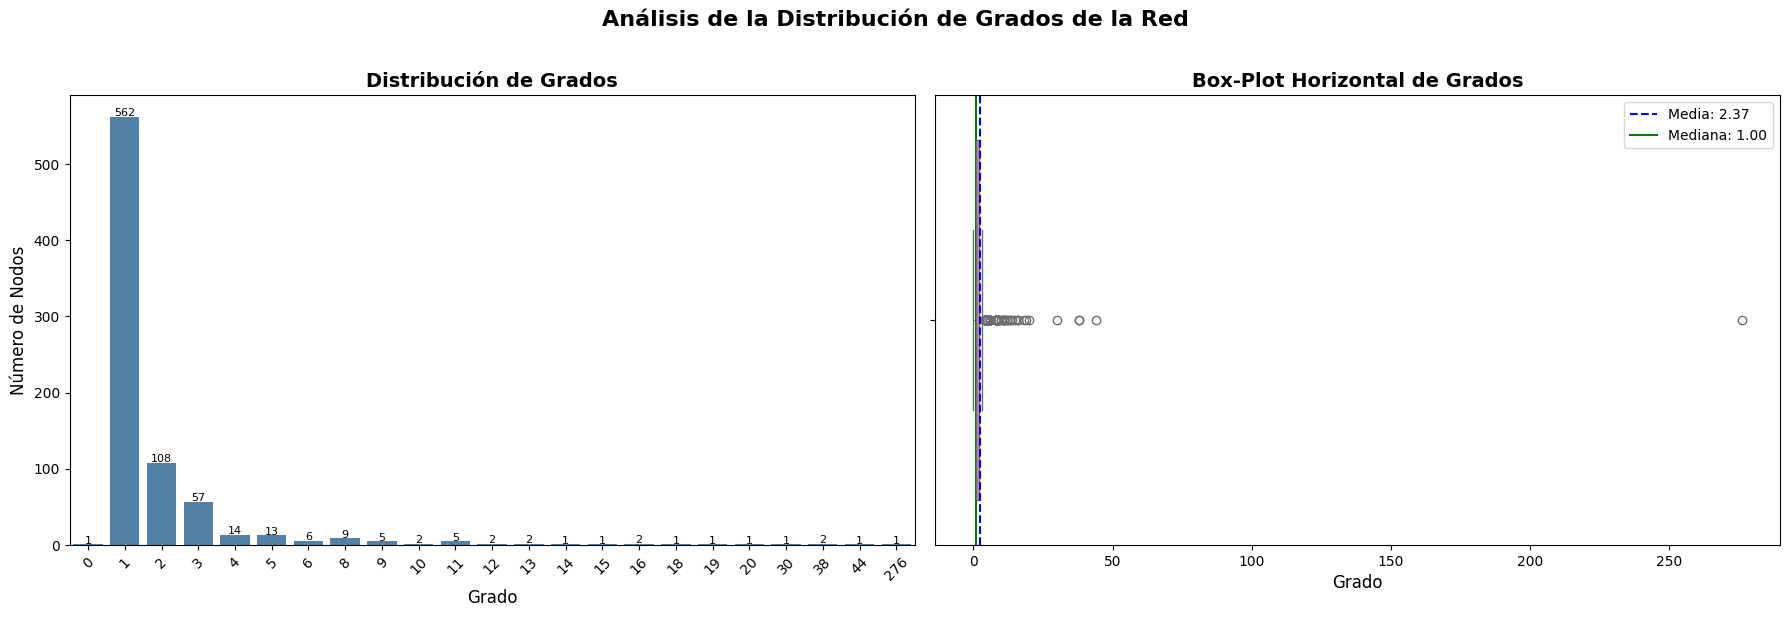

In [46]:
# Calculamos la distribución de grados
degree_sequence = sorted(degrees.values(), reverse=True)
degree_count = pd.Series(degree_sequence).value_counts().sort_index()

# Graficamos la distribución de grados
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar plot
sns.barplot(x=degree_count.index, y=degree_count.values, color='steelblue', ax=axes[0])
axes[0].set_title("Distribución de Grados", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Grado", fontsize=12)
axes[0].set_ylabel("Número de Nodos", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(degree_count.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=8)

# Box plot horizontal
deg_series = pd.Series(degree_sequence)

sns.boxplot(x=deg_series, orient='h', color='lightcoral', ax=axes[1])
axes[1].set_title("Box-Plot Horizontal de Grados", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Grado", fontsize=12)
axes[1].set_ylabel("")

# Añadimos estadísticas al boxplot
median = deg_series.median()
mean = deg_series.mean()
axes[1].axvline(mean, color='blue', linestyle='--', linewidth=1.5, label=f'Media: {mean:.2f}')
axes[1].axvline(median, color='green', linestyle='-', linewidth=1.5, label=f'Mediana: {median:.2f}')
axes[1].legend(fontsize=10)

plt.suptitle("Análisis de la Distribución de Grados de la Red", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

----